# Plots for paper

Curated, paper-ready figures built from the same `probing/experiment.py` output
tree as `analyse_probing_results.ipynb` (see that notebook's header for the full
output layout reference). Where that notebook is an exploratory dashboard over
*every* run, this one is a small set of specific comparisons -- each one driven
entirely by the config cell below, so renaming a model, swapping which token
counts as "central", or adding a new family to compare is a one-line edit here,
not a hunt through plotting code.

**Handles in-progress runs on purpose**: probing is launched as many independent
SLURM jobs (one per split), so at any time some (model, token, probe) combination
may have 0 finished splits yet, or a probe may be explicitly `skipped` for a given
split (e.g. too few usable cells). Every plot below skips missing bars rather than
crashing, and prints what it couldn't find -- re-run a cell after more jobs finish
and the gaps fill in.

## Sections

1. **Context aggregation** (`cell_type_composition`, `cell_count`, `cell_density`):
   overall performance, CLS vs. central token, and the 100→448 resolution
   improvement.
2. **Cell-level performance** (`area`): central tokens at 100 vs. 448
   resolution across all models, and `PhikonV2_448` vs. its masked counterpart.


In [26]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))


def _load_dotenv(path: Path) -> None:
    """Minimal `.env` loader (KEY=value per line) -- avoids an extra dependency.
    Mirrors how every other entry point in this repo expects env vars to be set
    (see src/python/code_configs/paths.py)."""
    if not path.exists():
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key, value = key.strip(), value.strip()
        if value:
            os.environ.setdefault(key, value)


_load_dotenv(REPO_ROOT / ".env")


In [27]:
import math

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Paper-ish defaults -- tweak freely, doesn't affect any data/plot logic below.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "font.size": 9,
    "legend.fontsize": 8,
})


## Config -- everything the notebook is parameterized by

Every plotting function further down takes its models/tokens/probes as
arguments defaulting to the constants defined here -- so a one-off comparison is
just a different call with different lists, and a permanent rename/addition is a
one-line edit in this cell (re-run from here down).

`MODEL_LABELS`'s keys are the exact `model_name` path segment (see
`configs/probing_colon.yaml`'s `data.model_name`, i.e. the top-level folder name
under each `OUTPUTS_ROOTS` entry) -- **edit this dict first** if your actual
folder names differ from the ones filled in below.


In [28]:
OUTPUTS_ROOTS = [Path("../outputs_probing_colon")]

# ── models ───────────────────────────────────────────────────────────────────
# model_name (folder under OUTPUTS_ROOTS) -> display label used on every axis/
# legend below. Add/remove/rename models here; every list further down (in this
# cell) just references these same keys.
MODEL_LABELS: dict[str, str] = {
    "HOptimus1":                   "H-Optimus-1",
    "HOptimus1_100_resized":       "H-Optimus-1",
    "PhikonV2_448":                "Phikon-v2",
    "PhikonV2_100_resized":        "Phikon-v2",
    "PhikonV2_448_masked":         "Phikon-v2 (masked)",
    "UNI2_448_resized":            "UNI2",
    "UNI2_100_resized":            "UNI2",
    "UNI2_specific_tokens_folder": "UNI2 (specific tokens)",
    "virchow_v2":                  "Virchow2",
    "virchow_v2_100_resized":      "Virchow2",
}

# ── tokens ("embeddings" path segment, see load_probe_summaries below) ──────
def embeddings_segment(keys: list[str]) -> str:
    """Mirrors experiment.py's `_embeddings_folder_name`: the `embeddings` path
    segment a `data.embeddings_datasets` config list produces is its entries,
    sorted and "_"-joined (or "default" if empty, meaning "average every
    embeddings_* key found in the h5 file"). Use this to build TOKEN_CENTRAL (or
    any other multi-dataset token combo) so it always matches what a real run's
    folder name would actually be."""
    return "_".join(sorted(keys)) if keys else "default"


TOKEN_CLS = "cls"
# "Central" token = the four central ViT-patch tokens (top_left/top_right/
# bottom_left/bottom_right -- extract_embeddings.py's "four central-token
# patches", saved alongside CLS by default), mean-pooled together via
# `data.embeddings_datasets: [top_left, top_right, bottom_left, bottom_right]`
# -- NOT embeddings_nucleus/embeddings_cell (the boundary-overlap mean-pooled
# tokens, a separate thing extract_embeddings.py can also save). Edit
# TOKEN_CENTRAL_KEYS if you actually mean one of those, or a different subset.
TOKEN_CENTRAL_KEYS = ["top_left", "top_right", "bottom_left", "bottom_right"]
TOKEN_CENTRAL = embeddings_segment(TOKEN_CENTRAL_KEYS)

# embeddings segment -> display label.
TOKEN_LABELS: dict[str, str] = {
    TOKEN_CLS: "CLS",
    TOKEN_CENTRAL: "central (4-patch avg)",
}

# ── section 1: context aggregation ──────────────────────────────────────────
CONTEXT_PROBES = ["cell_type_composition", "cell_count", "cell_density"]
CONTEXT_PX_LIST = [224, 448, 1344]

# Models included in the "overall context-probe performance" overview plot, and
# which token that overview is computed on. Defaults to one variant per model
# family (the native/448 resolution) rather than every MODEL_LABELS key -- the
# 100-resized/masked variants share a display label with their family's main
# entry (by design, so 1d/2a/2b can group them), so mixing both resolutions into
# this overview would draw two identically-labelled bars per family. Pass a
# different `models=` list (e.g. list(MODEL_LABELS) for literally everything) to
# override.
CONTEXT_OVERVIEW_MODELS = ["HOptimus1", "PhikonV2_448", "UNI2_448_resized",
                           "UNI2_specific_tokens_folder", "virchow_v2"]
CONTEXT_OVERVIEW_TOKEN = TOKEN_CENTRAL

# Models compared for the CLS vs. central difference -- each must have
# both TOKEN_CLS and TOKEN_CENTRAL runs finished under the same model_name.
CLS_VS_CENTRAL_MODELS = ["HOptimus1", "PhikonV2_448", "UNI2_specific_tokens_folder", "virchow_v2"]

# family label -> {"100": model_name at 100px resize, "448": model_name at
# native/448 resize} -- used by the 100->448 improvement plot (context probes)
# and the cell-level area resolution comparison. Only TOKEN_CENTRAL is compared
# across resolutions, per how these families are actually organized.
RESOLUTION_FAMILIES: dict[str, dict[str, str]] = {
    "H-Optimus-1": {"100": "HOptimus1_100_resized", "448": "HOptimus1"},
    "Phikon-v2":   {"100": "PhikonV2_100_resized",  "448": "PhikonV2_448"},
    "UNI2":        {"100": "UNI2_100_resized",      "448": "UNI2_448_resized"},
    "Virchow2":    {"100": "virchow_v2_100_resized", "448": "virchow_v2"},
}

# ── section 2: cell-level performance ───────────────────────────────────────
CELL_LEVEL_PROBE = "area"

# unmasked vs. masked pair for the area-probe masking comparison, and which
# token to compare them on.
MASK_COMPARISON: dict[str, str] = {"unmasked": "PhikonV2_448", "masked": "PhikonV2_448_masked"}
MASK_COMPARISON_TOKEN = TOKEN_CENTRAL

# ── which run to load ────────────────────────────────────────────────────────
# Paper plots should come from one fixed correction/mapping/matching -- unlike
# analyse_probing_results.ipynb, which keeps correction_name as a comparison
# axis. Set to None to auto-detect (only works if the loaded roots contain a
# single value); if a forced value matches 0 rows, loading below falls back to
# keeping everything and prints what's actually available, rather than silently
# producing empty plots.
CORRECTION_NAME = "Base"
MAPPING = None
MATCHING = None

# ── figure export ────────────────────────────────────────────────────────────
SAVE_FIGURES = False
FIGURES_DIR = Path("../figures_paper")


## Loading

Same two-pass loader as `analyse_probing_results.ipynb` (see that notebook's
header for the full rationale) -- duplicated here rather than imported so this
notebook stays runnable on its own; if you change one, consider mirroring the
change in the other.


In [17]:
SCHEMA = ("model_name", "correction_name", "mapping", "matching", "embeddings")


def _flatten(prefix: str, d: dict) -> dict:
    return {f"{prefix}_{k}": v for k, v in d.items()}


def _split_idx(split_label: str) -> int | None:
    return None if split_label == "same_wsi_split" else int(split_label.removeprefix("split_"))


def load_probe_summaries(root: Path) -> pd.DataFrame:
    """One row per (run, probe) from every probes_summary.yaml under root --
    includes skipped probes (skipped=True, reason=..., no metrics). A probe that
    hasn't finished running for a given split simply has no key in that split's
    probes_summary.yaml yet (see experiment.py's merge-on-write), so it produces
    no row at all here -- not a `skipped` one."""
    rows: list[dict] = []
    for summary_path in sorted(root.rglob("probes_summary.yaml")):
        parts = summary_path.relative_to(root).parts[:-1]  # drop the filename itself
        if len(parts) != len(SCHEMA) + 1:  # + split_label
            print(f"[skip] unexpected path depth ({len(parts)} != {len(SCHEMA) + 1}): {summary_path}")
            continue
        meta = dict(zip(SCHEMA, parts[:-1]))
        split_label = parts[-1]

        with open(summary_path) as f:
            probes = yaml.safe_load(f) or {}

        for probe_name, entry in probes.items():
            rows.append({
                **meta, "split_label": split_label, "split_idx": _split_idx(split_label),
                "is_same_wsi": split_label == "same_wsi_split",
                "probe_dir": summary_path.parent / probe_name.replace("@", "_"),
                "probe": probe_name, **(entry or {}),
            })
    return pd.DataFrame(rows)


def load_probe_details(df: pd.DataFrame) -> pd.DataFrame:
    """Enrich non-skipped rows with their probe's own results_summary.yaml --
    needed for the per-class R2 breakdown (test_r2_frac_<class>) the
    cell_type_composition plot below uses; the top-level selection_metric columns
    already come from probes_summary.yaml alone."""
    extra_rows = []
    for _, row in df.iterrows():
        extra: dict = {}
        if not row.get("skipped", True):
            path = Path(row["probe_dir"]) / "results_summary.yaml"
            if path.exists():
                with open(path) as f:
                    summary = yaml.safe_load(f)
                val_metrics = dict(summary.get("best_val_metrics") or {})
                test_metrics = dict(summary.get("best_test_metrics") or {})
                val_metrics.pop("selection_metric", None)
                test_metrics.pop("selection_metric", None)
                extra = {
                    "task_type": summary.get("task_type"), "target_columns": summary.get("target_columns"),
                    "n_train": summary.get("n_train"), "n_val": summary.get("n_val"), "n_test": summary.get("n_test"),
                    **_flatten("val", val_metrics),
                    **_flatten("test", test_metrics),
                }
        extra_rows.append(extra)
    extra_df = pd.DataFrame(extra_rows, index=df.index)
    return pd.concat([df, extra_df], axis=1)


def filter_or_report(df: pd.DataFrame, col: str, forced) -> pd.DataFrame:
    """If forced is not None, keep only rows with that value -- falling back to
    everything (with a warning listing what's actually available) if 0 rows
    match, instead of silently producing empty plots. If forced is None,
    passthrough when the column already has a single value; warn and keep
    everything if it mixes more than one (set the corresponding config constant
    above to pick one)."""
    values = sorted(df[col].dropna().unique().tolist())
    if forced is not None:
        filtered = df[df[col] == forced]
        if filtered.empty:
            print(f"[warning] {col}={forced!r} matches 0 rows -- available {col} values: {values}. "
                  f"Keeping all rows for now.")
            return df
        return filtered
    if len(values) > 1:
        print(f"[warning] multiple {col!r} values found {values} -- "
              f"set {col.upper()} above to filter to one; keeping all of them for now")
    return df


results_df = pd.concat([load_probe_summaries(root) for root in OUTPUTS_ROOTS], ignore_index=True)
assert not results_df.empty, f"no probes_summary.yaml found under {[str(r.resolve()) for r in OUTPUTS_ROOTS]}"
results_df = load_probe_details(results_df)

for _col, _forced in (("correction_name", CORRECTION_NAME), ("mapping", MAPPING), ("matching", MATCHING)):
    results_df = filter_or_report(results_df, _col, _forced)

ALL_MODEL_NAMES = sorted(results_df["model_name"].unique())
ALL_EMBEDDINGS_SEGMENTS = sorted(results_df["embeddings"].unique())
ALL_PROBES = sorted(results_df["probe"].unique())

_unknown_models = [m for m in ALL_MODEL_NAMES if m not in MODEL_LABELS]
print(f"Loaded {len(results_df)} (run x probe) rows.")
print(f"model_name segments found on disk: {ALL_MODEL_NAMES}")
if _unknown_models:
    print(f"[warning] found on disk but missing from MODEL_LABELS: {_unknown_models} -- add them there.")
print(f"embeddings segments found on disk: {ALL_EMBEDDINGS_SEGMENTS}")
if TOKEN_CLS not in ALL_EMBEDDINGS_SEGMENTS or TOKEN_CENTRAL not in ALL_EMBEDDINGS_SEGMENTS:
    print(f"[warning] TOKEN_CLS={TOKEN_CLS!r} / TOKEN_CENTRAL={TOKEN_CENTRAL!r} -- "
          f"one of these isn't among the embeddings segments actually found above.")
print(f"probes found on disk: {ALL_PROBES}")
results_df.head()


[warning] correction_name='Base' matches 0 rows -- available correction_name values: ['raw']. Keeping all rows for now.
Loaded 2019 (run x probe) rows.
model_name segments found on disk: ['HOptimus1', 'HOptimus1_100_resized', 'PhikonV2_100_resized', 'PhikonV2_448', 'PhikonV2_448_masked', 'UNI2_100_resized', 'UNI2_448_resized', 'UNI2_specific_tokens_folder', 'virchow_v2', 'virchow_v2_100_resized']
embeddings segments found on disk: ['bottom_left_bottom_right_top_left_top_right', 'cls', 'default', 'nucleus']
probes found on disk: ['area', 'cell_count@1344px', 'cell_count@224px', 'cell_count@448px', 'cell_density@1344px', 'cell_density@224px', 'cell_density@448px', 'cell_type_classification', 'cell_type_composition@1344px', 'cell_type_composition@224px', 'cell_type_composition@448px', 'eccentricity', 'orientation']


,model_name,correction_name,mapping,matching,embeddings,split_label,split_idx,is_same_wsi,probe_dir,probe,best_lambda,skipped,test_selection_metric,val_selection_metric,reason,task_type,target_columns,n_train,n_val,n_test,...,test_r2_frac_Malignant,test_r2_frac_Myeloid,test_r2_frac_Stromal,test_r2_frac_Unknown,val_r2_eccentricity,test_r2_eccentricity,val_mean_angular_error_deg,val_r2_orientation_cos2,val_r2_orientation_sin2,test_mean_angular_error_deg,test_r2_orientation_cos2,test_r2_orientation_sin2,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,area,1000.0,False,0.540005,0.473784,NaN,regression,[log1p_area],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@1344px,1000.0,False,0.425902,-0.282275,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@224px,1000.0,False,0.695877,0.229010,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@448px,1000.0,False,0.638218,-0.032640,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_density@1344px,1000.0,False,0.455490,-0.138532,NaN,regression,[log1p_cell_density_per_100px2],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data completeness -- what hasn't finished running yet

Cross-tabulates every (model, token, probe) combination this notebook's config
cell references against what's actually loaded: `missing` (0 rows -- that job
hasn't produced any split output yet), `skipped` (ran, but every split marked
that probe `skipped`, e.g. too few usable cells), `partial` (some splits fit,
some skipped), `done` (every found split fit cleanly). Re-check this after more
SLURM jobs land instead of guessing from a plot's gaps.


In [18]:
def probe_key(name: str, context_px: int | None) -> str:
    return f"{name}@{context_px}px" if context_px is not None else name


CONTEXT_PROBE_KEYS = [probe_key(p, c) for p in CONTEXT_PROBES for c in CONTEXT_PX_LIST]
ALL_PROBE_KEYS_OF_INTEREST = CONTEXT_PROBE_KEYS + [CELL_LEVEL_PROBE]


def completeness_table(df: pd.DataFrame, models: list[str], tokens: list[str], probe_keys: list[str]) -> pd.DataFrame:
    rows = []
    for m in models:
        for tok in tokens:
            for pkey in probe_keys:
                sub = df[(df["model_name"] == m) & (df["embeddings"] == tok)
                         & (df["probe"] == pkey) & (~df["is_same_wsi"])]
                n_total = len(sub)
                n_skipped = int((sub["skipped"] == True).sum())  # noqa: E712
                n_fit = int((sub["skipped"] == False).sum())  # noqa: E712
                status = ("missing" if n_total == 0 else
                          "skipped" if n_fit == 0 else
                          "partial" if n_skipped > 0 else "done")
                rows.append({"model": m, "token": tok, "probe": pkey,
                             "n_splits_fit": n_fit, "n_splits_skipped": n_skipped, "status": status})
    return pd.DataFrame(rows)


_all_models_of_interest = sorted(set(CONTEXT_OVERVIEW_MODELS) | set(CLS_VS_CENTRAL_MODELS)
                                  | {m for fam in RESOLUTION_FAMILIES.values() for m in fam.values()}
                                  | set(MASK_COMPARISON.values()))
_completeness = completeness_table(
    results_df, _all_models_of_interest, [TOKEN_CLS, TOKEN_CENTRAL], ALL_PROBE_KEYS_OF_INTEREST,
)
print(_completeness["status"].value_counts().to_string())
_completeness[_completeness["status"] != "done"].sort_values(["status", "model", "probe"])


status
done       180
missing     20


,model,token,probe,n_splits_fit,n_splits_skipped,status
49,PhikonV2_100_resized,cls,area,0,0,missing
45,PhikonV2_100_resized,cls,cell_count@1344px,0,0,missing
43,PhikonV2_100_resized,cls,cell_count@224px,0,0,missing
44,PhikonV2_100_resized,cls,cell_count@448px,0,0,missing
48,PhikonV2_100_resized,cls,cell_density@1344px,0,0,missing
46,PhikonV2_100_resized,cls,cell_density@224px,0,0,missing
47,PhikonV2_100_resized,cls,cell_density@448px,0,0,missing
42,PhikonV2_100_resized,cls,cell_type_composition@1344px,0,0,missing
40,PhikonV2_100_resized,cls,cell_type_composition@224px,0,0,missing
41,PhikonV2_100_resized,cls,cell_type_composition@448px,0,0,missing


## Plotting helpers

Generic, reusable across every comparison below: `mean_std_metric` pulls one
(mean, std, n) triple across LWO splits for a single (model, token, probe)
combo (`nan` if nothing fit yet); `grouped_bar_panel` draws one grouped-bar
subplot from a `models x hues` grid of such values, silently leaving a gap (and
reporting it) for any `nan` cell instead of erroring.


In [19]:
def _metric_grid(n: int, figsize_per=(5.0, 3.8)):
    ncols = 2 if n > 1 else 1
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows), squeeze=False)
    axes = axes.flatten()
    for ax in axes[n:]:
        ax.axis("off")
    return fig, axes


def mean_std_metric(df: pd.DataFrame, model_name: str, embeddings: str, probe: str,
                     value_col: str = "test_selection_metric") -> tuple[float, float, int]:
    """(mean, std, n_splits_fit) of value_col across LWO splits for one exact
    (model_name, embeddings, probe) run -- (nan, nan, 0) if nothing has fit yet."""
    sub = df[(df["model_name"] == model_name) & (df["embeddings"] == embeddings)
             & (df["probe"] == probe) & (~df["is_same_wsi"]) & (df["skipped"] == False)]  # noqa: E712
    vals = sub[value_col].dropna()
    if vals.empty:
        return float("nan"), float("nan"), 0
    std = float(vals.std()) if len(vals) > 1 else 0.0
    return float(vals.mean()), std, len(vals)


def grouped_bar_panel(ax, x_labels: list[str], hue_labels: list[str],
                       means: np.ndarray, stds: np.ndarray, ylabel: str) -> list[tuple[str, str]]:
    """means/stds: (len(x_labels), len(hue_labels)) arrays, nan where that
    (x, hue) combo has no fitted data -- that bar is simply omitted. Returns the
    list of (x_label, hue_label) pairs that were missing, for the caller to
    report."""
    n_x, n_hue = len(x_labels), len(hue_labels)
    x = np.arange(n_x)
    width = 0.8 / max(n_hue, 1)
    missing: list[tuple[str, str]] = []
    for j, hue in enumerate(hue_labels):
        offset = x + j * width - 0.4 + width / 2
        labeled = False
        for i in range(n_x):
            m, s = means[i, j], stds[i, j]
            if not np.isfinite(m):
                missing.append((x_labels[i], hue))
                continue
            ax.bar(offset[i], m, width=width, yerr=(s if np.isfinite(s) else None), capsize=3,
                   color=f"C{j % 10}", label=(hue if not labeled else None))
            labeled = True
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.grid(axis="y", alpha=0.3)
    if n_hue > 1:
        ax.legend(fontsize=7)
    return missing


def report_missing(where: str, missing: list[tuple]) -> None:
    if not missing:
        return
    print(f"[{where}] {len(missing)} bar(s) with no fitted data (not yet run, or filtered out):")
    for row in missing:
        print("   ", row)


def save_fig(fig, name: str) -> None:
    if not SAVE_FIGURES:
        return
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig.savefig(FIGURES_DIR / f"{name}.{ext}", dpi=200, bbox_inches="tight")
    print(f"[save_fig] wrote {FIGURES_DIR / name}.{{png,pdf}}")


def _labels(items: list[str], mapping: dict[str, str]) -> list[str]:
    return [mapping.get(x, x) for x in items]


def _check_known(models: list[str], where: str) -> None:
    unknown = [m for m in models if m not in MODEL_LABELS]
    if unknown:
        print(f"[warning] {where}: {unknown} not in MODEL_LABELS -- add a display label there.")


## Section 1 -- Context aggregation

`cell_type_composition`, `cell_count`, `cell_density`: how much of a cell's
*neighbourhood* (a `context_px x context_px` window centred on it) is linearly
recoverable from its embedding (see `probes/context.py`).


### 1a. Overall probe performance (R2, val vs. test)

One panel per `(probe, context_px)`, bars = models, grouped by val/test
`selection_metric` (R2, mean ± std across LWO splits) -- the "R2 and other
metric" view: val vs. test is the natural pairing here since every context
probe's own `selection_metric` already *is* R2 (`r2_mean`, see `Probe.eval_metrics`
in `probes/base.py`). Swap `metrics=` below for a different pairing if you'd
rather compare something else.


[plot_context_overview] 18 bar(s) with no fitted data (not yet run, or filtered out):
    ('cell_type_composition@224px', 'UNI2', 'val')
    ('cell_type_composition@224px', 'UNI2', 'test')
    ('cell_type_composition@448px', 'UNI2', 'val')
    ('cell_type_composition@448px', 'UNI2', 'test')
    ('cell_type_composition@1344px', 'UNI2', 'val')
    ('cell_type_composition@1344px', 'UNI2', 'test')
    ('cell_count@224px', 'UNI2', 'val')
    ('cell_count@224px', 'UNI2', 'test')
    ('cell_count@448px', 'UNI2', 'val')
    ('cell_count@448px', 'UNI2', 'test')
    ('cell_count@1344px', 'UNI2', 'val')
    ('cell_count@1344px', 'UNI2', 'test')
    ('cell_density@224px', 'UNI2', 'val')
    ('cell_density@224px', 'UNI2', 'test')
    ('cell_density@448px', 'UNI2', 'val')
    ('cell_density@448px', 'UNI2', 'test')
    ('cell_density@1344px', 'UNI2', 'val')
    ('cell_density@1344px', 'UNI2', 'test')


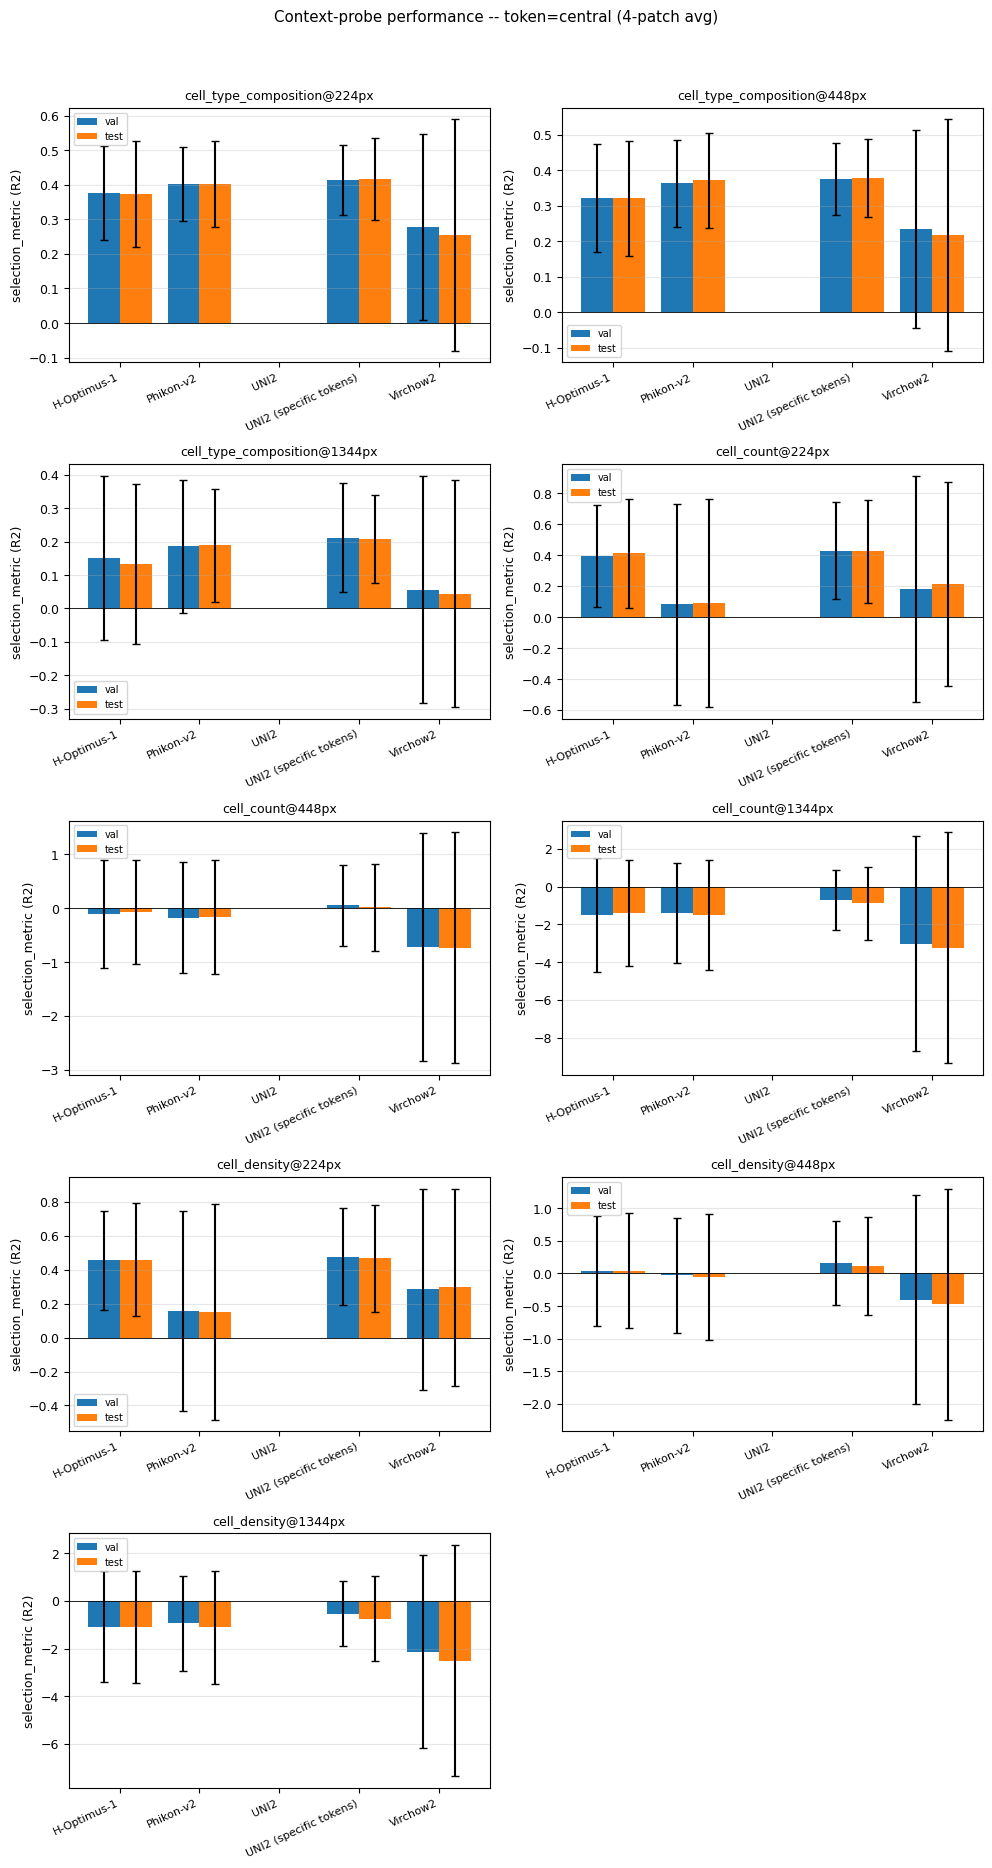

In [20]:
def plot_context_overview(df: pd.DataFrame, models: list[str] = CONTEXT_OVERVIEW_MODELS,
                           token: str = CONTEXT_OVERVIEW_TOKEN, probes: list[str] = CONTEXT_PROBES,
                           context_px_list: list[int] = CONTEXT_PX_LIST,
                           metrics: tuple[str, str] = ("val_selection_metric", "test_selection_metric")):
    _check_known(models, "plot_context_overview")
    probe_keys = [probe_key(p, c) for p in probes for c in context_px_list]
    x_labels = _labels(models, MODEL_LABELS)
    hue_labels = [m.replace("_selection_metric", "") for m in metrics]

    fig, axes = _metric_grid(len(probe_keys))
    all_missing = []
    for ax, pkey in zip(axes, probe_keys):
        means = np.full((len(models), len(metrics)), np.nan)
        stds = np.full((len(models), len(metrics)), np.nan)
        for i, m in enumerate(models):
            for j, metric in enumerate(metrics):
                means[i, j], stds[i, j], _n = mean_std_metric(df, m, token, pkey, metric)
        missing = grouped_bar_panel(ax, x_labels, hue_labels, means, stds, "selection_metric (R2)")
        all_missing += [(pkey, *row) for row in missing]
        ax.set_title(pkey, fontsize=9)
    fig.suptitle(f"Context-probe performance -- token={TOKEN_LABELS.get(token, token)}")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    report_missing("plot_context_overview", all_missing)
    save_fig(fig, "context_overview")
    plt.show()


plot_context_overview(results_df)


### 1b. `cell_type_composition` per-class breakdown (other metric: per-target R2)

`cell_type_composition`'s `selection_metric` is the *mean* R2 across every
cell-type fraction it regresses -- this breaks that mean back out per class
(`test_r2_frac_<class>`), since a high mean can hide a class the embedding
barely captures. One heatmap per `context_px`, rows = models, columns = cell
type; blank cells = not fit yet.


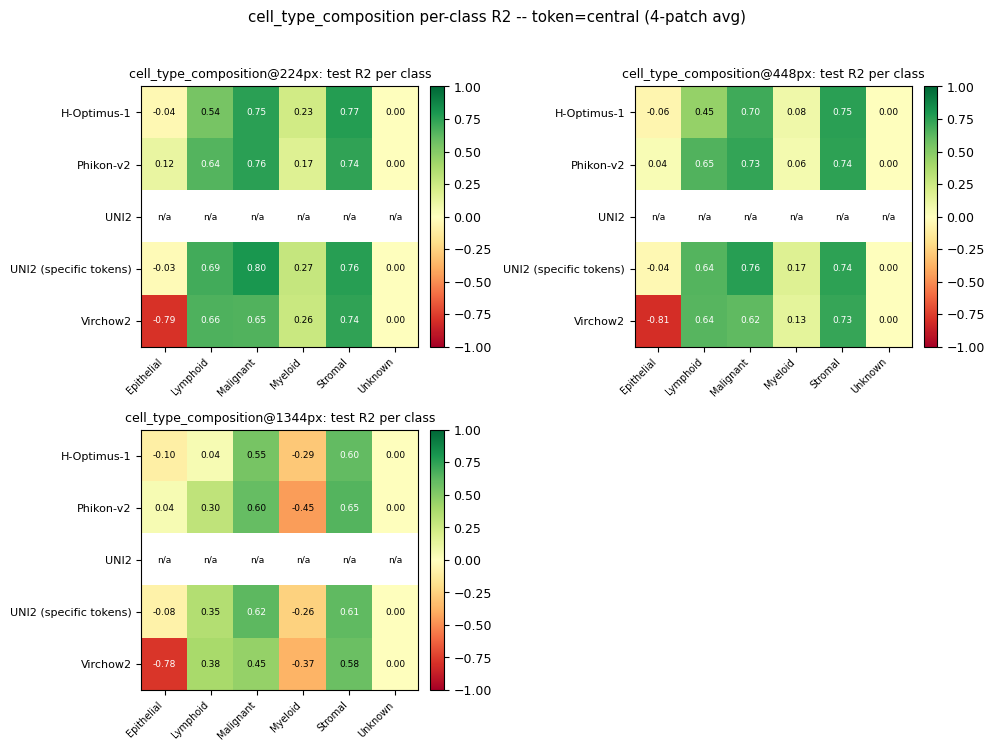

In [21]:
def plot_composition_breakdown(df: pd.DataFrame, models: list[str] = CONTEXT_OVERVIEW_MODELS,
                                token: str = CONTEXT_OVERVIEW_TOKEN, context_px_list: list[int] = CONTEXT_PX_LIST):
    _check_known(models, "plot_composition_breakdown")
    x_labels = _labels(models, MODEL_LABELS)

    fig, axes = _metric_grid(len(context_px_list))
    for ax, cpx in zip(axes, context_px_list):
        pkey = probe_key("cell_type_composition", cpx)
        sub = df[(df["model_name"].isin(models)) & (df["embeddings"] == token)
                 & (df["probe"] == pkey) & (~df["is_same_wsi"]) & (df["skipped"] == False)]  # noqa: E712
        class_cols = sorted(c for c in df.columns if c.startswith("test_r2_frac_"))
        class_names = [c.removeprefix("test_r2_frac_") for c in class_cols]
        if not class_cols:
            ax.set_title(f"{pkey} -- no fitted rows yet", fontsize=9)
            ax.axis("off")
            continue

        grid = np.full((len(models), len(class_cols)), np.nan)
        for i, m in enumerate(models):
            m_sub = sub[sub["model_name"] == m]
            if m_sub.empty:
                continue
            for k, col in enumerate(class_cols):
                if col in m_sub:
                    grid[i, k] = m_sub[col].mean()

        im = ax.imshow(grid, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(len(x_labels)))
        ax.set_yticklabels(x_labels, fontsize=8)
        for i in range(grid.shape[0]):
            for k in range(grid.shape[1]):
                v = grid[i, k]
                ax.text(k, i, f"{v:.2f}" if np.isfinite(v) else "n/a",
                        ha="center", va="center", fontsize=6.5,
                        color="black" if not np.isfinite(v) else ("white" if abs(v) > 0.6 else "black"))
        ax.set_title(f"{pkey}: test R2 per class", fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"cell_type_composition per-class R2 -- token={TOKEN_LABELS.get(token, token)}")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    save_fig(fig, "composition_breakdown")
    plt.show()


plot_composition_breakdown(results_df)


### 1c. CLS vs. central token

Same overall-performance view as 1a, but fixing the metric to `test_selection_metric`
and putting the two tokens side by side per model instead.


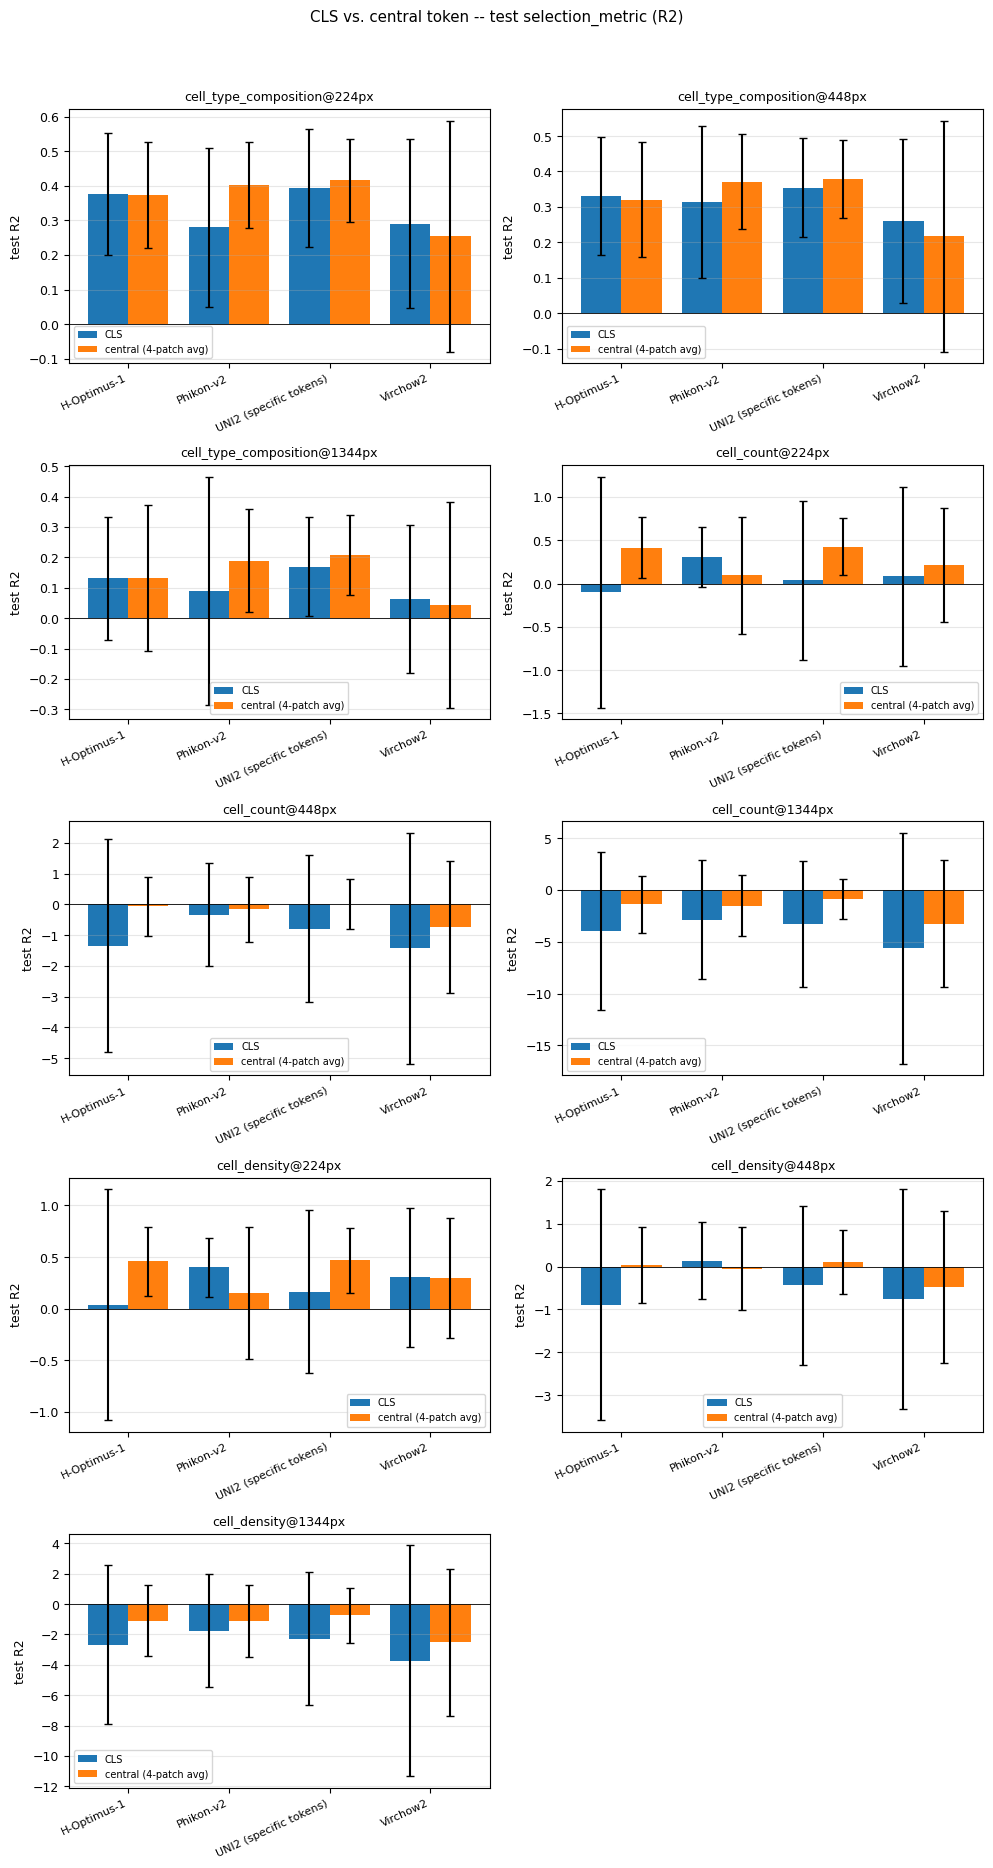

In [22]:
def plot_token_comparison(df: pd.DataFrame, models: list[str] = CLS_VS_CENTRAL_MODELS,
                           tokens: tuple[str, str] = (TOKEN_CLS, TOKEN_CENTRAL),
                           probes: list[str] = CONTEXT_PROBES, context_px_list: list[int] = CONTEXT_PX_LIST,
                           value_col: str = "test_selection_metric"):
    _check_known(models, "plot_token_comparison")
    probe_keys = [probe_key(p, c) for p in probes for c in context_px_list]
    x_labels = _labels(models, MODEL_LABELS)
    hue_labels = _labels(list(tokens), TOKEN_LABELS)

    fig, axes = _metric_grid(len(probe_keys))
    all_missing = []
    for ax, pkey in zip(axes, probe_keys):
        means = np.full((len(models), len(tokens)), np.nan)
        stds = np.full((len(models), len(tokens)), np.nan)
        for i, m in enumerate(models):
            for j, tok in enumerate(tokens):
                means[i, j], stds[i, j], _n = mean_std_metric(df, m, tok, pkey, value_col)
        missing = grouped_bar_panel(ax, x_labels, hue_labels, means, stds, "test R2")
        all_missing += [(pkey, *row) for row in missing]
        ax.set_title(pkey, fontsize=9)
    fig.suptitle("CLS vs. central token -- test selection_metric (R2)")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    report_missing("plot_token_comparison", all_missing)
    save_fig(fig, "cls_vs_central_context")
    plt.show()


plot_token_comparison(results_df)


### 1d. 100 → 448 resolution improvement (central tokens)

x = model family, hues = the two resolutions in `RESOLUTION_FAMILIES`; the second
row of panels shows the raw delta (448 − 100) so the improvement itself is
directly readable rather than eyeballed off two bars.


[plot_resolution_improvement (levels)] 9 bar(s) with no fitted data (not yet run, or filtered out):
    ('cell_type_composition@224px', 'UNI2', '448px')
    ('cell_type_composition@448px', 'UNI2', '448px')
    ('cell_type_composition@1344px', 'UNI2', '448px')
    ('cell_count@224px', 'UNI2', '448px')
    ('cell_count@448px', 'UNI2', '448px')
    ('cell_count@1344px', 'UNI2', '448px')
    ('cell_density@224px', 'UNI2', '448px')
    ('cell_density@448px', 'UNI2', '448px')
    ('cell_density@1344px', 'UNI2', '448px')


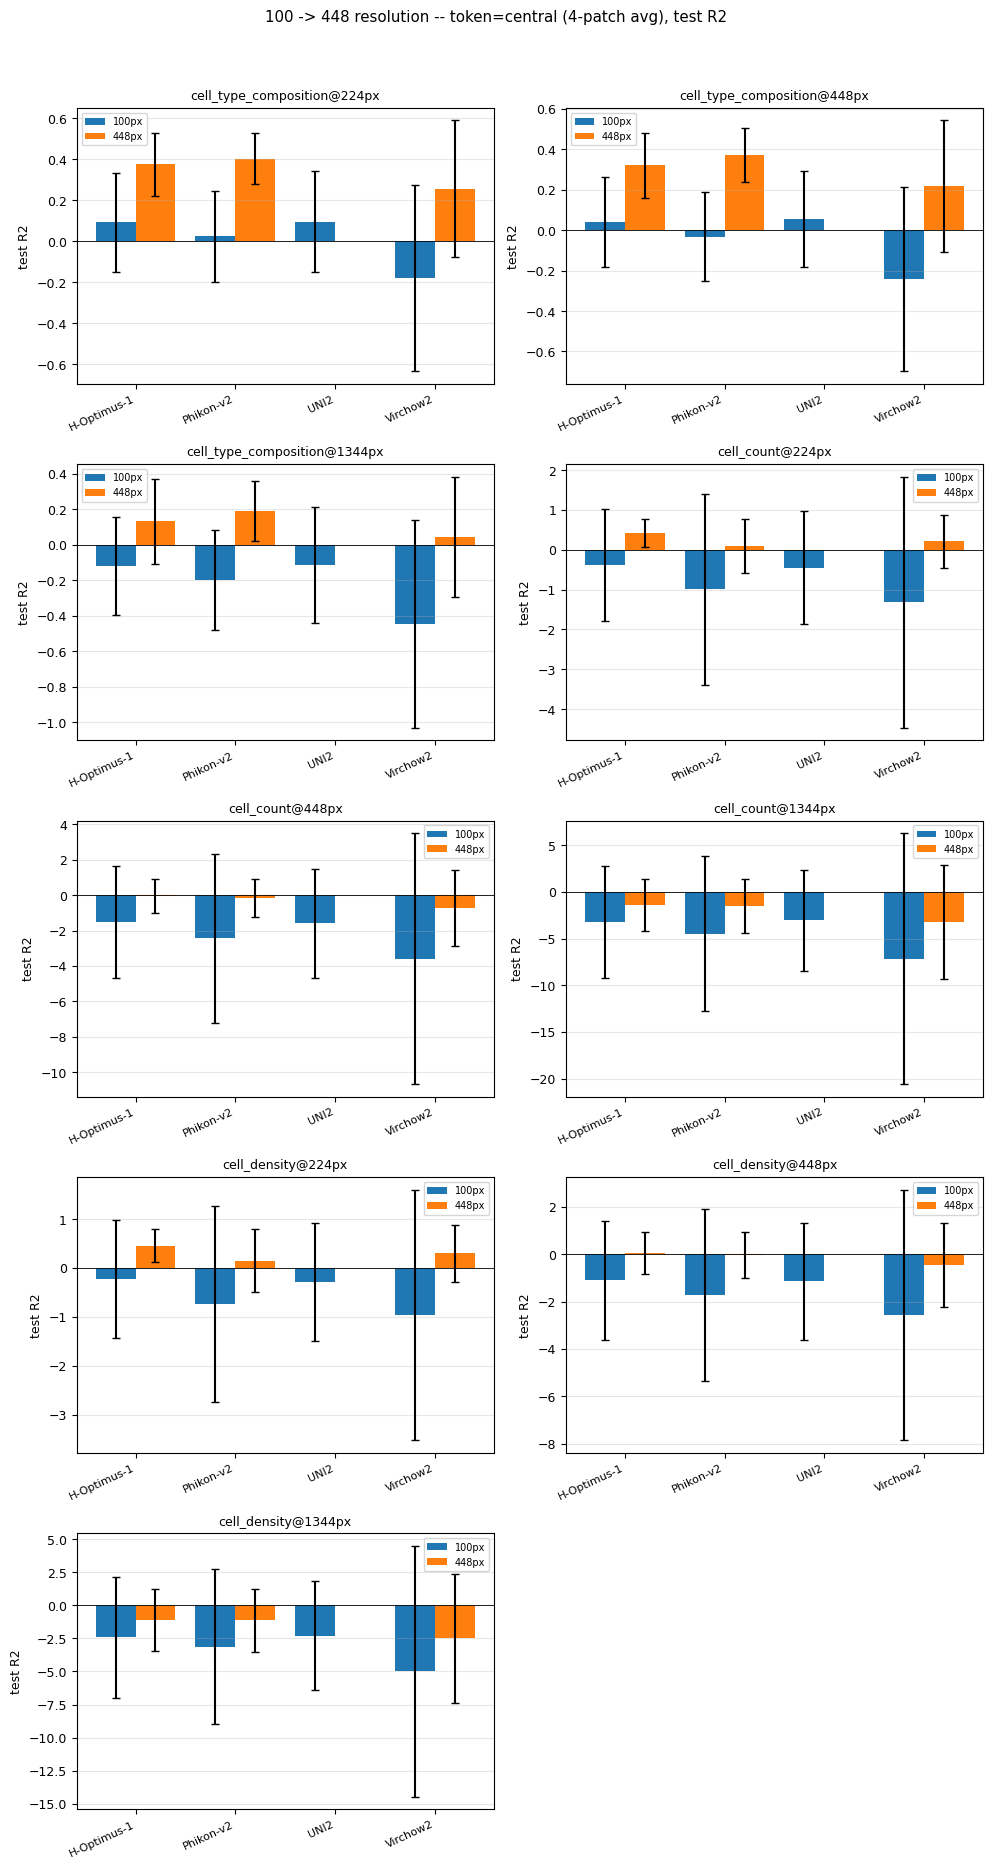

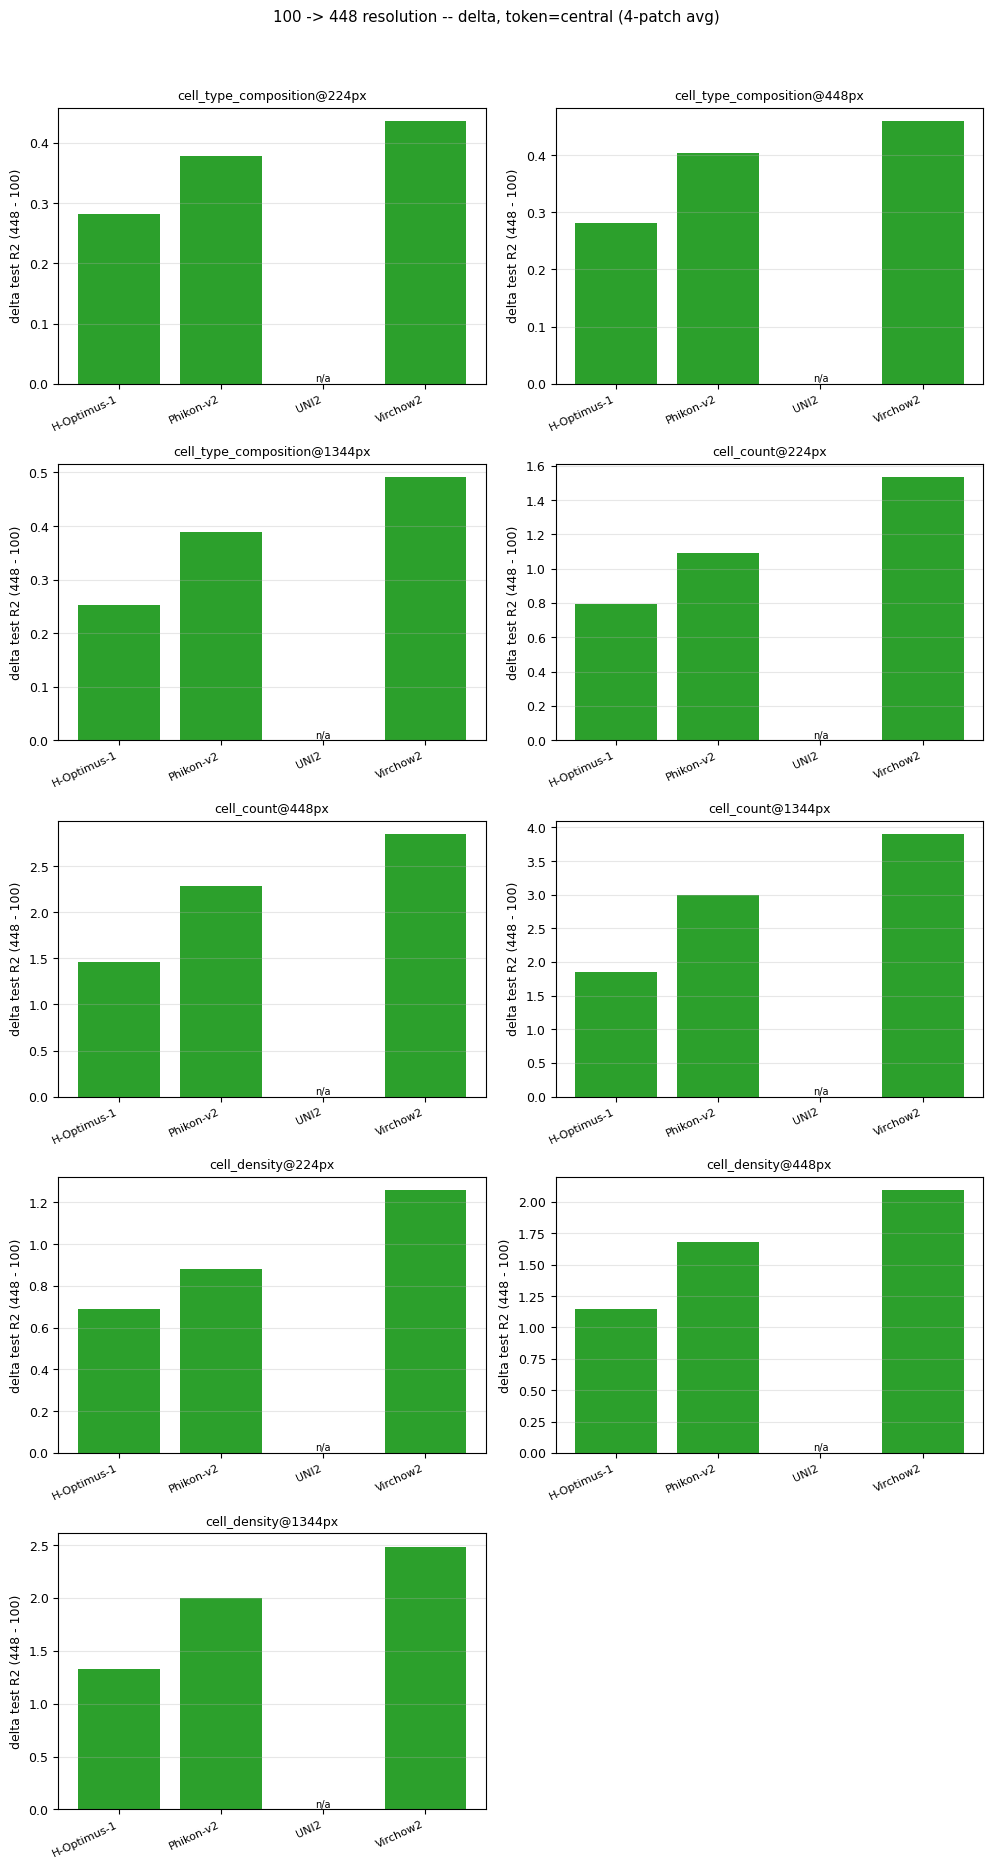

In [23]:
def plot_resolution_improvement(df: pd.DataFrame, families: dict[str, dict[str, str]] = RESOLUTION_FAMILIES,
                                 token: str = TOKEN_CENTRAL, probes: list[str] = CONTEXT_PROBES,
                                 context_px_list: list[int] = CONTEXT_PX_LIST,
                                 value_col: str = "test_selection_metric"):
    _check_known([m for fam in families.values() for m in fam.values()], "plot_resolution_improvement")
    probe_keys = [probe_key(p, c) for p in probes for c in context_px_list]
    family_names = list(families)
    resolutions = ["100", "448"]

    fig, axes = _metric_grid(len(probe_keys))
    all_missing = []
    for ax, pkey in zip(axes, probe_keys):
        means = np.full((len(family_names), 2), np.nan)
        stds = np.full((len(family_names), 2), np.nan)
        for i, fam in enumerate(family_names):
            for j, res in enumerate(resolutions):
                model_name = families[fam].get(res)
                if model_name is None:
                    continue
                means[i, j], stds[i, j], _n = mean_std_metric(df, model_name, token, pkey, value_col)
        missing = grouped_bar_panel(ax, family_names, [f"{r}px" for r in resolutions], means, stds, "test R2")
        all_missing += [(pkey, *row) for row in missing]
        ax.set_title(pkey, fontsize=9)
    fig.suptitle(f"100 -> 448 resolution -- token={TOKEN_LABELS.get(token, token)}, test R2")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    report_missing("plot_resolution_improvement (levels)", all_missing)
    save_fig(fig, "resolution_improvement_context")
    plt.show()

    fig, axes = _metric_grid(len(probe_keys))
    for ax, pkey in zip(axes, probe_keys):
        deltas = np.full(len(family_names), np.nan)
        for i, fam in enumerate(family_names):
            m100, m448 = families[fam].get("100"), families[fam].get("448")
            v100, _s, _n = mean_std_metric(df, m100, token, pkey, value_col) if m100 else (np.nan, np.nan, 0)
            v448, _s, _n = mean_std_metric(df, m448, token, pkey, value_col) if m448 else (np.nan, np.nan, 0)
            deltas[i] = v448 - v100
        colors = ["tab:green" if d > 0 else "tab:red" for d in np.nan_to_num(deltas)]
        ax.bar(range(len(family_names)), np.nan_to_num(deltas), color=colors)
        for i, d in enumerate(deltas):
            if not np.isfinite(d):
                ax.text(i, 0, "n/a", ha="center", va="bottom", fontsize=7)
        ax.set_xticks(range(len(family_names)))
        ax.set_xticklabels(family_names, rotation=25, ha="right", fontsize=8)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_ylabel("delta test R2 (448 - 100)")
        ax.grid(axis="y", alpha=0.3)
        ax.set_title(pkey, fontsize=9)
    fig.suptitle(f"100 -> 448 resolution -- delta, token={TOKEN_LABELS.get(token, token)}")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    save_fig(fig, "resolution_improvement_context_delta")
    plt.show()


plot_resolution_improvement(results_df)


## Section 2 -- Cell-level performance (`area` probe)

`area`: the probed cell's *own* Xenium boundary-polygon area (log1p-regressed
by default, see `configs/probing_colon.yaml`'s `probes.area.log_transform`) --
independent of any context window, contrast with Section 1.


### 2a. Central tokens: 100 vs. 448, all models


[plot_area_resolution] 1 bar(s) with no fitted data (not yet run, or filtered out):
    ('UNI2', '448px')


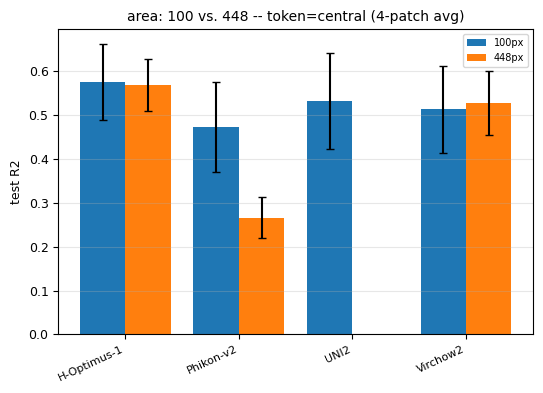

In [24]:
def plot_area_resolution(df: pd.DataFrame, families: dict[str, dict[str, str]] = RESOLUTION_FAMILIES,
                          token: str = TOKEN_CENTRAL, probe: str = CELL_LEVEL_PROBE,
                          value_col: str = "test_selection_metric"):
    _check_known([m for fam in families.values() for m in fam.values()], "plot_area_resolution")
    family_names = list(families)
    resolutions = ["100", "448"]

    means = np.full((len(family_names), 2), np.nan)
    stds = np.full((len(family_names), 2), np.nan)
    for i, fam in enumerate(family_names):
        for j, res in enumerate(resolutions):
            model_name = families[fam].get(res)
            if model_name is None:
                continue
            means[i, j], stds[i, j], _n = mean_std_metric(df, model_name, token, probe, value_col)

    fig, ax = plt.subplots(figsize=(5.5, 4))
    missing = grouped_bar_panel(ax, family_names, [f"{r}px" for r in resolutions], means, stds, "test R2")
    ax.set_title(f"{probe}: 100 vs. 448 -- token={TOKEN_LABELS.get(token, token)}", fontsize=10)
    fig.tight_layout()
    report_missing("plot_area_resolution", missing)
    save_fig(fig, "area_resolution")
    plt.show()


plot_area_resolution(results_df)


### 2b. `PhikonV2_448` vs. `PhikonV2_448_masked` (central tokens)


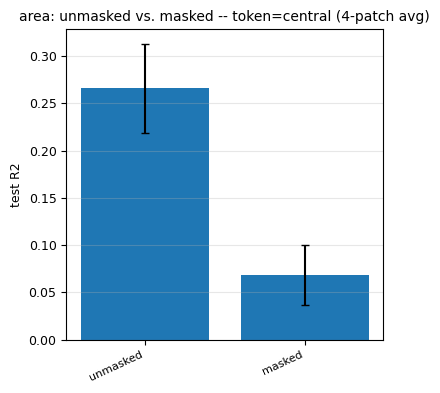

In [25]:
def plot_area_masking(df: pd.DataFrame, pair: dict[str, str] = MASK_COMPARISON,
                       token: str = MASK_COMPARISON_TOKEN, probe: str = CELL_LEVEL_PROBE,
                       value_col: str = "test_selection_metric"):
    _check_known(list(pair.values()), "plot_area_masking")
    labels = list(pair)

    means = np.full((len(labels), 1), np.nan)
    stds = np.full((len(labels), 1), np.nan)
    for i, label in enumerate(labels):
        means[i, 0], stds[i, 0], _n = mean_std_metric(df, pair[label], token, probe, value_col)

    fig, ax = plt.subplots(figsize=(4, 4))
    missing = grouped_bar_panel(ax, labels, ["test R2"], means, stds, "test R2")
    ax.set_title(f"{probe}: unmasked vs. masked -- token={TOKEN_LABELS.get(token, token)}", fontsize=10)
    fig.tight_layout()
    report_missing("plot_area_masking", missing)
    save_fig(fig, "area_masking")
    plt.show()


plot_area_masking(results_df)


## Extending this notebook

New comparison = new call to `mean_std_metric` (one exact model/token/probe
combo's mean±std) feeding a `models x hues` grid into `grouped_bar_panel` (one
subplot). `_metric_grid(n)` lays out `n` such subplots; `report_missing` prints
whichever cells came back `nan`. Every plotting function above is a short
example of this pattern -- copy the closest one and change what it loops over.
